# Model predykcyjny oparty na regresji liniowej

Celem analizy jest stworzenie modelu umożliwiającego predykcje ceny samochodu w zależności od jego specyfikacji. Lista potemcjalnych regresorów:
* Marka -> bazując na wiedzy rynku samochodowego niektóre marki do co zasady są droższe od innych np. BMW jest droższe od Renault
* Przebieg -> bazując na intuicji, im niższy przebieg, tym droższy samochód powinien być
* Moc silnika -> droższe samochody powinny mieć mocniejszy silnik
* Rocznik -> poza outlierami im starsze auto tym tańsze powinno być

## Przygotowanie danych

In [54]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from sklearn.linear_model import LinearRegression
sns.set_theme()

In [55]:
data = pd.read_csv('cars_data.csv')
data

,Marka,Model,Cena,Waluta,Paliwo,Przebieg,Rocznik,Skrzynia biegów,Pojemność silnika,Pojemność_znana
0,Alfa Romeo,Alfa Romeo 147,3000,PLN,Benzyna,159000,2008,Manualna,2.00,0
1,Volvo,Volvo XC 60,129999,PLN,Benzyna,127000,2018,Automatyczna,2.40,0
2,Ford,Ford B-MAX,22900,PLN,Benzyna,161000,2016,Manualna,1.60,0
3,Jaguar,Jaguar I-Pace EV400 AWD SE,69900,PLN,Elektryczny,135125,2019,Automatyczna,2.00,0
4,Cupra,Cupra Formentor VZ 2.0 TSI 4Drive DSG,119999,PLN,Benzyna,81800,2020,Automatyczna,2.00,1
...,...,...,...,...,...,...,...,...,...,...
11993,SsangYong/KGM,SsangYong/KGM Tivoli,35550,PLN,Benzyna,76000,2015,Manualna,2.00,0
11994,Mercedes-Benz,Mercedes-Benz GLE,280000,PLN,Benzyna,61000,2022,Automatyczna,3.00,0
11995,Land Rover,Land Rover Range Rover,79900,PLN,Diesel,290000,2014,Automatyczna,3.00,0
11996,Volkswagen,Volkswagen T-Roc 1.5 TSI R-Line DSG,109900,PLN,Benzyna,14200,2024,Automatyczna,1.50,1


In [56]:
pd.set_option('display.float_format', '{:.2f}'.format)
data.describe(include='all')

,Marka,Model,Cena,Waluta,Paliwo,Przebieg,Rocznik,Skrzynia biegów,Pojemność silnika,Pojemność_znana
count,11998,11998,11998.00,11998,11998,11998.00,11998.00,11998,11998.00,11998.00
unique,99,6619,NaN,1,8,NaN,NaN,2,NaN,NaN
top,BMW,BMW Seria 3,NaN,PLN,Benzyna,NaN,NaN,Automatyczna,NaN,NaN
freq,920,80,NaN,11998,6462,NaN,NaN,6035,NaN,NaN
mean,NaN,NaN,77316.92,NaN,NaN,142182.88,2016.26,NaN,1.79,0.43
std,NaN,NaN,100117.19,NaN,NaN,100359.24,7.03,NaN,0.59,0.49
min,NaN,NaN,1350.00,NaN,NaN,0.00,1951.00,NaN,1.00,0.00
25%,NaN,NaN,22900.00,NaN,NaN,66600.00,2012.00,NaN,1.50,0.00
50%,NaN,NaN,47000.00,NaN,NaN,139850.00,2017.00,NaN,1.60,0.00
75%,NaN,NaN,95000.00,NaN,NaN,202185.00,2022.00,NaN,2.00,1.00


## PDF dla regresorów

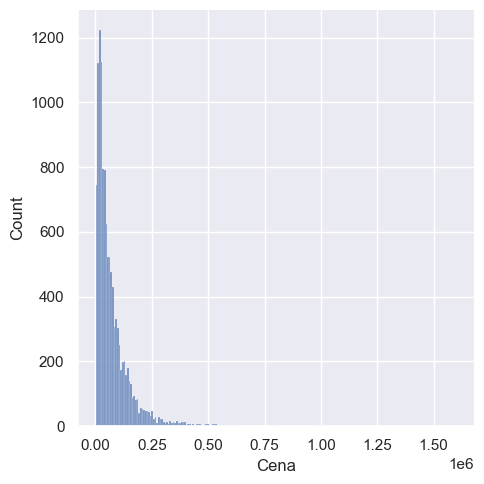

In [57]:
sns.displot(data['Cena'])

## Outliery

In [74]:
q_cena = data['Cena'].quantile(0.99)
data = data[data['Cena'] < q_cena]
data.describe(include='all')

,Marka,Model,Cena,Waluta,Paliwo,Przebieg,Rocznik,Skrzynia biegów,Pojemność silnika,Pojemność_znana
count,11878,11878,11878.00,11878,11878,11878.00,11878.00,11878,11878.00,11878.00
unique,95,6555,NaN,1,8,NaN,NaN,2,NaN,NaN
top,BMW,BMW Seria 3,NaN,PLN,Benzyna,NaN,NaN,Manualna,NaN,NaN
freq,894,80,NaN,11878,6388,NaN,NaN,5962,NaN,NaN
mean,NaN,NaN,70798.58,NaN,NaN,143476.11,2016.19,NaN,1.78,0.43
std,NaN,NaN,72354.24,NaN,NaN,99993.80,7.02,NaN,0.57,0.50
min,NaN,NaN,1350.00,NaN,NaN,0.00,1951.00,NaN,1.00,0.00
25%,NaN,NaN,22500.00,NaN,NaN,69000.00,2012.00,NaN,1.50,0.00
50%,NaN,NaN,46000.00,NaN,NaN,140121.50,2017.00,NaN,1.60,0.00
75%,NaN,NaN,93458.25,NaN,NaN,203000.00,2022.00,NaN,2.00,1.00


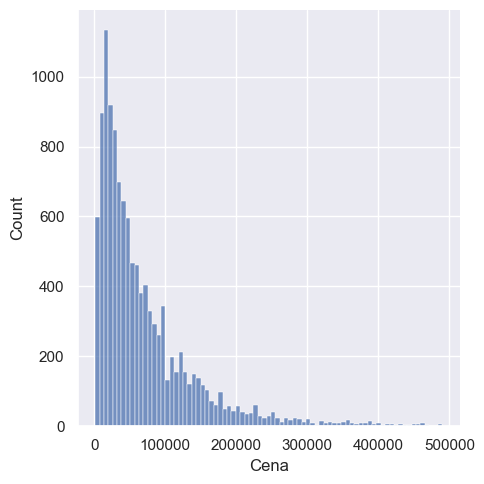

In [75]:
sns.displot(data['Cena'])

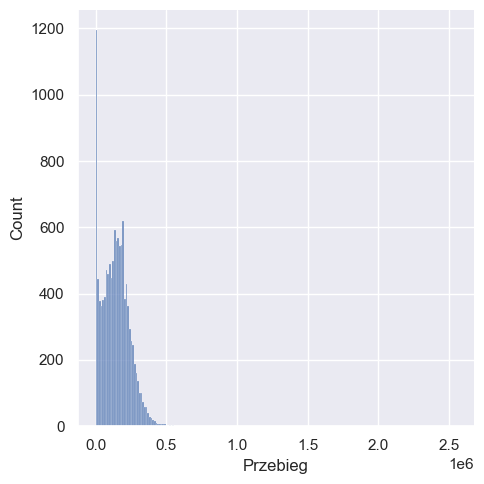

In [60]:
sns.displot(data['Przebieg'])

In [76]:
q_przebieg = data['Przebieg'].quantile(0.99)
data = data[data['Przebieg'] < q_przebieg]

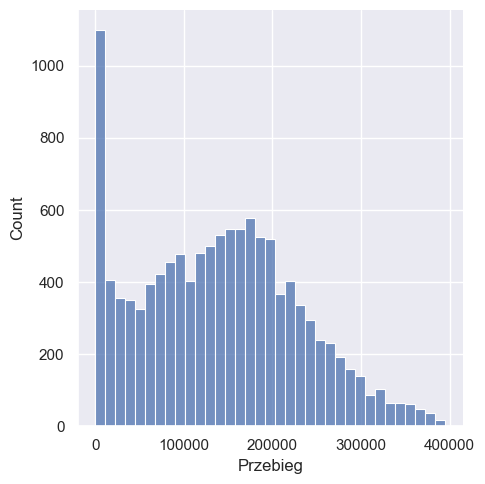

In [77]:
sns.displot(data['Przebieg'])

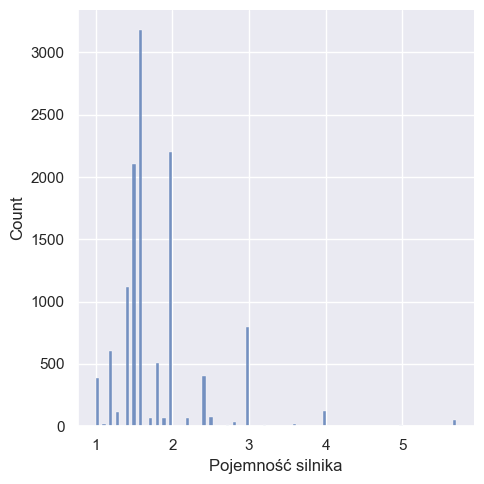

In [63]:
sns.displot(data["Pojemność silnika"])

In [78]:
q_pojemnosc = data['Pojemność silnika'].quantile(0.99)
data= data[data['Pojemność silnika'] < q_pojemnosc]

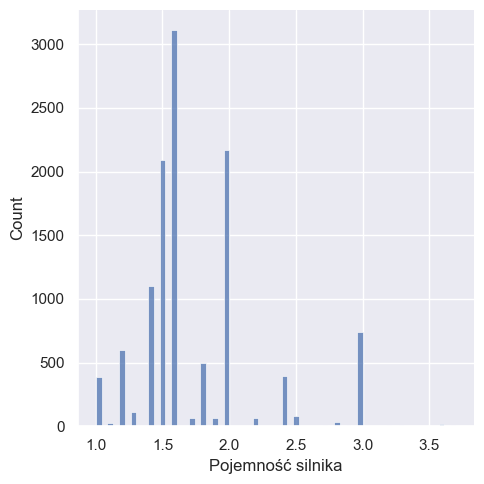

In [79]:
sns.displot(data['Pojemność silnika'])

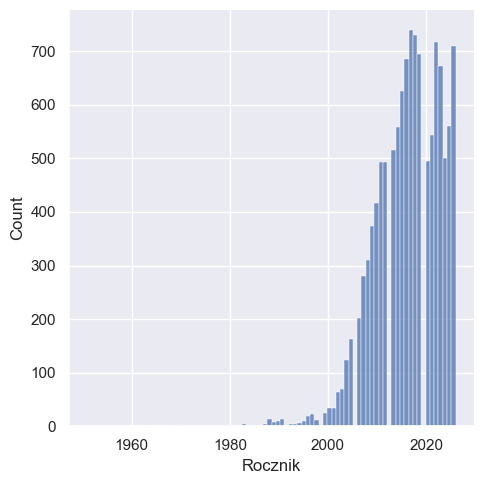

In [70]:
sns.displot(data['Rocznik'])

In [80]:
q_rocznik = data['Rocznik'].quantile(0.01)
data = data[data['Rocznik'] > q_rocznik]

In [81]:
data_cleaned = data.reset_index(drop=True)

In [82]:
data_cleaned.describe(include='all')

,Marka,Model,Cena,Waluta,Paliwo,Przebieg,Rocznik,Skrzynia biegów,Pojemność silnika,Pojemność_znana
count,11477,11477,11477.00,11477,11477,11477.00,11477.00,11477,11477.00,11477.00
unique,87,6350,NaN,1,8,NaN,NaN,2,NaN,NaN
top,BMW,BMW Seria 3,NaN,PLN,Benzyna,NaN,NaN,Manualna,NaN,NaN
freq,876,74,NaN,11477,6153,NaN,NaN,5787,NaN,NaN
mean,NaN,NaN,70001.14,NaN,NaN,140290.81,2016.59,NaN,1.74,0.44
std,NaN,NaN,70592.87,NaN,NaN,90275.01,6.15,NaN,0.46,0.50
min,NaN,NaN,1350.00,NaN,NaN,0.00,1997.00,NaN,1.00,0.00
25%,NaN,NaN,22900.00,NaN,NaN,69000.00,2012.00,NaN,1.50,0.00
50%,NaN,NaN,46499.00,NaN,NaN,140000.00,2017.00,NaN,1.60,0.00
75%,NaN,NaN,92250.00,NaN,NaN,201000.00,2022.00,NaN,2.00,1.00


## Założenia OLS
W tej części analizy nie będzie brany uwagę warunek braku autokorelacji, ponieważ obserwacje, którymi dysponujemy, nie pochodzą z danych szeregów czasowych ani danych panelowych. Są one po prostu snapshotem aktualnej sytuacji samochodów używanych na stronie www.otomoto.pl. Każdy wiersz pochodzi od innego klienta (poza nielicznymi wyjątkami), który chce sprzedać swój samochód za pośrednictwem platformy. Z logicznego punktu widzenia nie ma powodu, aby obserwacje były od siebie zależne.

### Linearność oraz homoscedastyczność

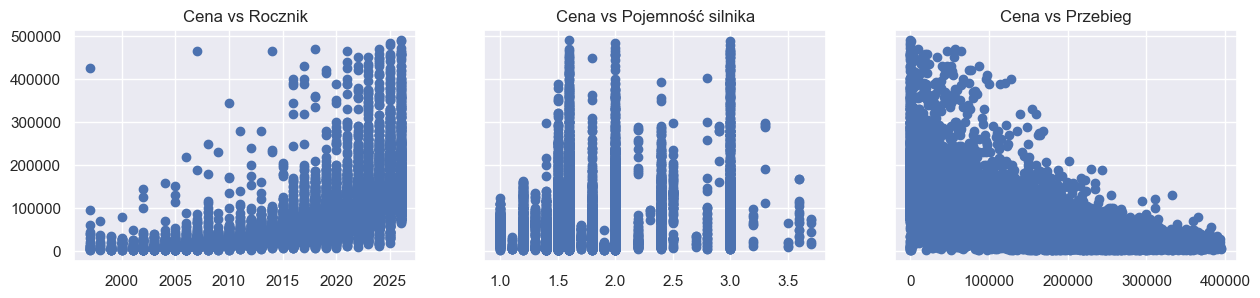

In [83]:
f, (ax1, ax2, ax3) = plt.subplots(1, 3, sharey=True, figsize=(15, 3))
ax1.scatter(data_cleaned['Rocznik'], data_cleaned['Cena'])
ax1.set_title('Cena vs Rocznik')
ax2.scatter(data_cleaned['Pojemność silnika'], data_cleaned['Cena'])
ax2.set_title('Cena vs Pojemność silnika')
ax3.scatter(data_cleaned['Przebieg'], data_cleaned['Cena'])
ax3.set_title('Cena vs Przebieg')

plt.show()

W powyższych danych można dostrzec wzorce, jednak zdecydowanie nie są one liniowe, co za tym idzie dane wymagają przekształcenia przy użyciu transformacji logarytmicznej.

In [84]:
log_cena = np.log(data_cleaned['Cena'])
data_cleaned['log_Cena'] = log_cena
data_cleaned.describe(include='all')

,Marka,Model,Cena,Waluta,Paliwo,Przebieg,Rocznik,Skrzynia biegów,Pojemność silnika,Pojemność_znana,log_Cena
count,11477,11477,11477.00,11477,11477,11477.00,11477.00,11477,11477.00,11477.00,11477.00
unique,87,6350,NaN,1,8,NaN,NaN,2,NaN,NaN,NaN
top,BMW,BMW Seria 3,NaN,PLN,Benzyna,NaN,NaN,Manualna,NaN,NaN,NaN
freq,876,74,NaN,11477,6153,NaN,NaN,5787,NaN,NaN,NaN
mean,NaN,NaN,70001.14,NaN,NaN,140290.81,2016.59,NaN,1.74,0.44,10.70
std,NaN,NaN,70592.87,NaN,NaN,90275.01,6.15,NaN,0.46,0.50,1.01
min,NaN,NaN,1350.00,NaN,NaN,0.00,1997.00,NaN,1.00,0.00,7.21
25%,NaN,NaN,22900.00,NaN,NaN,69000.00,2012.00,NaN,1.50,0.00,10.04
50%,NaN,NaN,46499.00,NaN,NaN,140000.00,2017.00,NaN,1.60,0.00,10.75
75%,NaN,NaN,92250.00,NaN,NaN,201000.00,2022.00,NaN,2.00,1.00,11.43


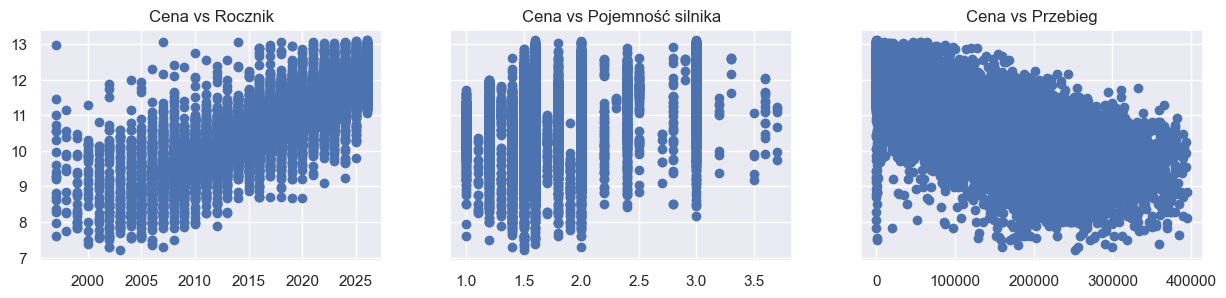

In [85]:
f, (ax1, ax2, ax3) = plt.subplots(1, 3, sharey=True, figsize=(15, 3))
ax1.scatter(data_cleaned['Rocznik'], data_cleaned['log_Cena'])
ax1.set_title('Cena vs Rocznik')
ax2.scatter(data_cleaned['Pojemność silnika'], data_cleaned['log_Cena'])
ax2.set_title('Cena vs Pojemność silnika')
ax3.scatter(data_cleaned['Przebieg'], data_cleaned['log_Cena'])
ax3.set_title('Cena vs Przebieg')

plt.show()

Powyższe wykresy pokazują przy okazji spełnienie warunku homoscedastyczności.

### Endogeniczność

Nie wykluczone, że to trzeba będzie po prostu poprawić

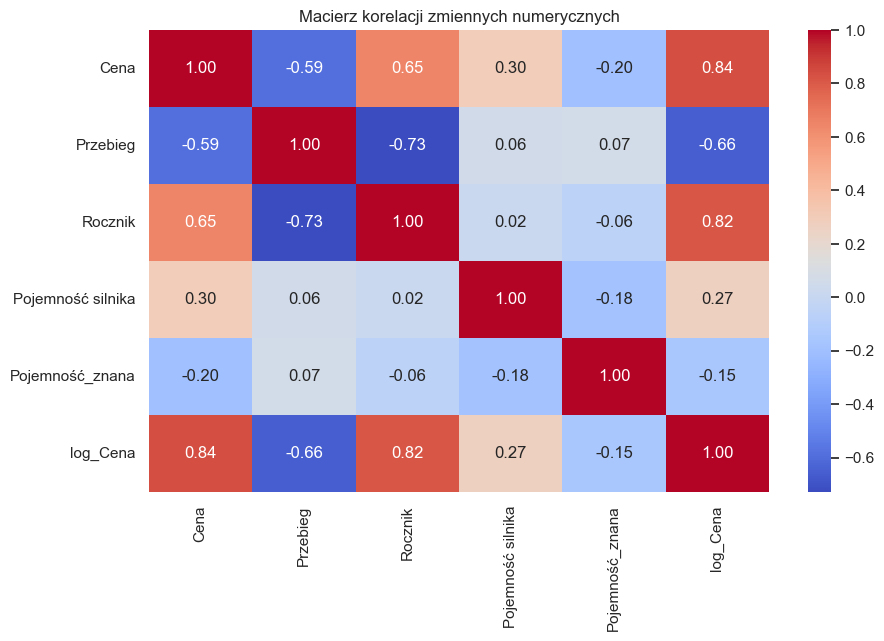

In [88]:
numeric_df = data_cleaned.select_dtypes(include=[np.number])

plt.figure(figsize=(10, 6))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Macierz korelacji zmiennych numerycznych")
plt.show()

Analiza macierzy korelacji wykazała silną współliniowość pomiędzy rocznikiem a przebiegiem pojazdu ($r = -0.73$). Choć nie narusza to bezpośrednio założenia o egzogeniczności w sensie rynkowym, wysoka współliniowość może prowadzić do problemów z multikolinearnością w modelu OLS.

### Multikolinearność
Na wstępnie można założyć, że logicznym będzie, że rok i przebieg będą ze sobą korelować

In [89]:
data_cleaned.columns.values

array(['Marka', 'Model', 'Cena', 'Waluta', 'Paliwo', 'Przebieg',
       'Rocznik', 'Skrzynia biegów', 'Pojemność silnika',
       'Pojemność_znana', 'log_Cena'], dtype=object)

Sprawdzenie multikolinearności przy pomocy współczynnika VIF.

In [91]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
variables = data_cleaned[['Rocznik', 'Pojemność silnika', 'Przebieg']]
vif = pd.DataFrame()
vif["VIF"] = [variance_inflation_factor(variables.values, i) for i in range(variables.shape[1])]
vif["features"] = variables.columns

In [92]:
vif

,VIF,features
0,17.13,Rocznik
1,15.49,Pojemność silnika
2,3.41,Przebieg


Po przeprowadzeniu analizy współczyynik dla zmiennych Rocznik oraz pojemność silnika wykazują bardzo wysoki poziom.
Mimo że wartości VIF dla rocznika i pojemności przekraczają tradycyjne progi ostrzegawcze (VIF > 10), zgodnie z podejściem m.in. P. Allisona, silna korelacja między zmiennymi kontrolnymi/objaśniającymi odzwierciedlającą realia rynkowe (starsze auta = wyższy przebieg) nie dyskwalifikuje modelu z dalszej predykcji, dopóki interpretujemy współczynniki ze świadomością ich powiązania.

## Zmienne kategoryczne

In [102]:
data_encoded = pd.get_dummies(data_cleaned, columns=['Marka', 'Paliwo', 'Skrzynia biegów'], drop_first=True)

In [103]:
data_encoded.head()

,Model,Cena,Waluta,Przebieg,Rocznik,Pojemność silnika,Pojemność_znana,log_Cena,Marka_Abarth,Marka_Acura,Marka_Aixam,Marka_Alfa Romeo,Marka_Aston Martin,Marka_Audi,Marka_BAIC,Marka_BAW,Marka_BMW,Marka_BMW-ALPINA,Marka_BYD,Marka_Bentley,Marka_Bestune,Marka_Buick,Marka_Cadillac,Marka_Changan,Marka_Chatenet,Marka_Chery,Marka_Chevrolet,Marka_Chrysler,Marka_Citroën,Marka_Cupra,Marka_DS Automobiles,Marka_Dacia,Marka_Daewoo,Marka_Daihatsu,Marka_Denza,Marka_Dodge,Marka_Dongfeng,Marka_FOTON,Marka_Ferrari,Marka_Fiat,...,Marka_Ligier,Marka_Lincoln,Marka_Lynk & Co,Marka_MG,Marka_MINI,Marka_Maserati,Marka_Mazda,Marka_Mercedes-Benz,Marka_Mercury,Marka_Microcar,Marka_Mitsubishi,Marka_Nissan,Marka_Omoda,Marka_Opel,Marka_Peugeot,Marka_Pontiac,Marka_Renault,Marka_SWM,Marka_Saab,Marka_Seat,Marka_Skoda,Marka_Smart,Marka_SsangYong/KGM,Marka_Subaru,Marka_Suzuki,Marka_Tata,Marka_Tesla,Marka_Toyota,Marka_Vanderhall,Marka_Volkswagen,Marka_Volvo,Marka_Xiaomi,Paliwo_Benzyna+CNG,Paliwo_Benzyna+LPG,Paliwo_Diesel,Paliwo_Elektryczny,Paliwo_Hybryda,Paliwo_Hybryda Plug-in,Paliwo_Wodór,Skrzynia biegów_Manualna
0,Alfa Romeo 147,3000,PLN,159000,2008,2.00,0,8.01,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True
1,Volvo XC 60,129999,PLN,127000,2018,2.40,0,11.78,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False
2,Ford B-MAX,22900,PLN,161000,2016,1.60,0,10.04,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True
3,Jaguar I-Pace EV400 AWD SE,69900,PLN,135125,2019,2.00,0,11.15,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False
4,Cupra Formentor VZ 2.0 TSI 4Drive DSG,119999,PLN,81800,2020,2.00,1,11.70,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False


In [104]:
data_encoded.columns.values

array(['Model', 'Cena', 'Waluta', 'Przebieg', 'Rocznik',
       'Pojemność silnika', 'Pojemność_znana', 'log_Cena', 'Marka_Abarth',
       'Marka_Acura', 'Marka_Aixam', 'Marka_Alfa Romeo',
       'Marka_Aston Martin', 'Marka_Audi', 'Marka_BAIC', 'Marka_BAW',
       'Marka_BMW', 'Marka_BMW-ALPINA', 'Marka_BYD', 'Marka_Bentley',
       'Marka_Bestune', 'Marka_Buick', 'Marka_Cadillac', 'Marka_Changan',
       'Marka_Chatenet', 'Marka_Chery', 'Marka_Chevrolet',
       'Marka_Chrysler', 'Marka_Citroën', 'Marka_Cupra',
       'Marka_DS Automobiles', 'Marka_Dacia', 'Marka_Daewoo',
       'Marka_Daihatsu', 'Marka_Denza', 'Marka_Dodge', 'Marka_Dongfeng',
       'Marka_FOTON', 'Marka_Ferrari', 'Marka_Fiat', 'Marka_Ford',
       'Marka_Forthing', 'Marka_GAC', 'Marka_GMC', 'Marka_Geely',
       'Marka_Honda', 'Marka_Hongqi', 'Marka_Hummer', 'Marka_Hyundai',
       'Marka_Infiniti', 'Marka_Inny', 'Marka_Iveco', 'Marka_JAC',
       'Marka_Jaecoo', 'Marka_Jaguar', 'Marka_Jeep', 'Marka_Jetour',
      

In [107]:
cols = ['log_Cena', 'Model', 'Waluta', 'Przebieg', 'Rocznik',
       'Pojemność silnika', 'Pojemność_znana', 'Marka_Abarth',
       'Marka_Acura', 'Marka_Aixam', 'Marka_Alfa Romeo',
       'Marka_Aston Martin', 'Marka_Audi', 'Marka_BAIC', 'Marka_BAW',
       'Marka_BMW', 'Marka_BMW-ALPINA', 'Marka_BYD', 'Marka_Bentley',
       'Marka_Bestune', 'Marka_Buick', 'Marka_Cadillac', 'Marka_Changan',
       'Marka_Chatenet', 'Marka_Chery', 'Marka_Chevrolet',
       'Marka_Chrysler', 'Marka_Citroën', 'Marka_Cupra',
       'Marka_DS Automobiles', 'Marka_Dacia', 'Marka_Daewoo',
       'Marka_Daihatsu', 'Marka_Denza', 'Marka_Dodge', 'Marka_Dongfeng',
       'Marka_FOTON', 'Marka_Ferrari', 'Marka_Fiat', 'Marka_Ford',
       'Marka_Forthing', 'Marka_GAC', 'Marka_GMC', 'Marka_Geely',
       'Marka_Honda', 'Marka_Hongqi', 'Marka_Hummer', 'Marka_Hyundai',
       'Marka_Infiniti', 'Marka_Inny', 'Marka_Iveco', 'Marka_JAC',
       'Marka_Jaecoo', 'Marka_Jaguar', 'Marka_Jeep', 'Marka_Jetour',
       'Marka_Kia', 'Marka_Lancia', 'Marka_Land Rover', 'Marka_Leapmotor',
       'Marka_Lexus', 'Marka_Ligier', 'Marka_Lincoln', 'Marka_Lynk & Co',
       'Marka_MG', 'Marka_MINI', 'Marka_Maserati', 'Marka_Mazda',
       'Marka_Mercedes-Benz', 'Marka_Mercury', 'Marka_Microcar',
       'Marka_Mitsubishi', 'Marka_Nissan', 'Marka_Omoda', 'Marka_Opel',
       'Marka_Peugeot', 'Marka_Pontiac', 'Marka_Renault', 'Marka_SWM',
       'Marka_Saab', 'Marka_Seat', 'Marka_Skoda', 'Marka_Smart',
       'Marka_SsangYong/KGM', 'Marka_Subaru', 'Marka_Suzuki',
       'Marka_Tata', 'Marka_Tesla', 'Marka_Toyota', 'Marka_Vanderhall',
       'Marka_Volkswagen', 'Marka_Volvo', 'Marka_Xiaomi',
       'Paliwo_Benzyna+CNG', 'Paliwo_Benzyna+LPG', 'Paliwo_Diesel',
       'Paliwo_Elektryczny', 'Paliwo_Hybryda', 'Paliwo_Hybryda Plug-in',
       'Paliwo_Wodór', 'Skrzynia biegów_Manualna']

In [114]:
data_accepted = data_encoded[cols]
data_accepted = data_accepted.drop(['Model', 'Waluta'], axis=1)
data_accepted.head()

,log_Cena,Przebieg,Rocznik,Pojemność silnika,Pojemność_znana,Marka_Abarth,Marka_Acura,Marka_Aixam,Marka_Alfa Romeo,Marka_Aston Martin,Marka_Audi,Marka_BAIC,Marka_BAW,Marka_BMW,Marka_BMW-ALPINA,Marka_BYD,Marka_Bentley,Marka_Bestune,Marka_Buick,Marka_Cadillac,Marka_Changan,Marka_Chatenet,Marka_Chery,Marka_Chevrolet,Marka_Chrysler,Marka_Citroën,Marka_Cupra,Marka_DS Automobiles,Marka_Dacia,Marka_Daewoo,Marka_Daihatsu,Marka_Denza,Marka_Dodge,Marka_Dongfeng,Marka_FOTON,Marka_Ferrari,Marka_Fiat,Marka_Ford,Marka_Forthing,Marka_GAC,...,Marka_Ligier,Marka_Lincoln,Marka_Lynk & Co,Marka_MG,Marka_MINI,Marka_Maserati,Marka_Mazda,Marka_Mercedes-Benz,Marka_Mercury,Marka_Microcar,Marka_Mitsubishi,Marka_Nissan,Marka_Omoda,Marka_Opel,Marka_Peugeot,Marka_Pontiac,Marka_Renault,Marka_SWM,Marka_Saab,Marka_Seat,Marka_Skoda,Marka_Smart,Marka_SsangYong/KGM,Marka_Subaru,Marka_Suzuki,Marka_Tata,Marka_Tesla,Marka_Toyota,Marka_Vanderhall,Marka_Volkswagen,Marka_Volvo,Marka_Xiaomi,Paliwo_Benzyna+CNG,Paliwo_Benzyna+LPG,Paliwo_Diesel,Paliwo_Elektryczny,Paliwo_Hybryda,Paliwo_Hybryda Plug-in,Paliwo_Wodór,Skrzynia biegów_Manualna
0,8.01,159000,2008,2.00,0,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True
1,11.78,127000,2018,2.40,0,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False
2,10.04,161000,2016,1.60,0,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,...,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True
3,11.15,135125,2019,2.00,0,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False
4,11.70,81800,2020,2.00,1,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False


## Model regresji liniowej

In [115]:
target = data_accepted['log_Cena']
inputs = data_accepted.drop('log_Cena', axis=1)

In [116]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaler.fit(inputs)

,copy,True
,with_mean,True
,with_std,True


In [117]:
inputs_scaled = scaler.transform(inputs)

In [119]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(inputs_scaled, target, test_size=0.2, random_state=420)

In [120]:
reg = LinearRegression()
reg.fit(x_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [121]:
y_hat = reg.predict(x_test)

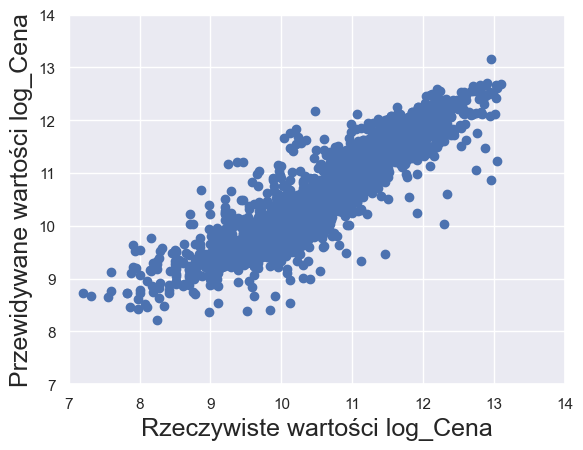

In [126]:
plt.scatter(y_test, y_hat)
plt.xlabel('Rzeczywiste wartości log_Cena',size=18)
plt.ylabel('Przewidywane wartości log_Cena',size=18)
plt.xlim(7, 14)
plt.ylim(7, 14)
plt.show()

Text(0.5, 1.0, 'Reszty PDF')

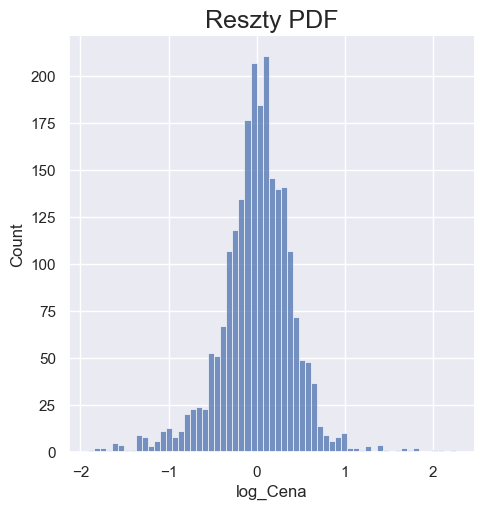

In [128]:
residuals = y_test - y_hat
sns.displot(residuals)
plt.title("Reszty PDF", size=18)
plt.title(("Reszty PDF"), size=18)

Wykres rozproszenia wartości rzeczywistych względem predykcji modelu na zbiorze testowym demonstruje silną korelację i stabilne dopasowanie liniowe. Chmura punktów koncentruje się wokół przekątnej, co świadczy o dobrej ogólnej skuteczności predykcyjnej modelu, choć na skrajnych wartościach (auta najdroższe) zauważalna jest nieco większa wariancja błędu, co jest typowe dla modeli rynkowych.

In [129]:
reg.score(x_train, y_train)

0.824510482757166

Model osiągnął współczynnik determinacji $R^2$ na poziomie 0.8245 na zbiorze treningowym. Oznacza to, że uwzględnione w modelowaniu cechy (rocznik, przebieg, pojemność silnika oraz zakodowane zmienne kategoryczne) wyjaśniają ponad 82% wariancji zlogarytmowanej ceny samochodów. Wynik ten wskazuje na silną moc predykcyjną modelu oraz dobrą poprawność dobroci dopasowania w warunkach rynku wtórnego

In [130]:
reg.intercept_

np.float64(10.70102270104038)

In [131]:
reg.coef_

array([-1.66155806e-01,  6.33702123e-01,  1.87061574e-01,  4.41416660e-03,
       -5.18343890e-04,  2.38347361e-03, -1.57104995e-02, -3.61125928e-02,
        2.19419350e-02, -3.11842572e-02, -2.45960493e-02,  9.14468601e-03,
        4.16374914e-02,  1.38777878e-16, -2.29438930e-02,  1.70387105e-02,
       -1.59811751e-02, -8.29833661e-03, -4.68224333e-03, -1.43341800e-02,
       -1.24900090e-16, -1.20726346e-02, -3.86330395e-02, -2.85280892e-02,
       -1.27649171e-01, -3.97739295e-02, -2.17736340e-02, -7.00718504e-02,
       -7.19056317e-03,  4.21950544e-06,  8.68735741e-03, -2.18858082e-02,
       -1.06711617e-02, -5.11233096e-03,  2.58545163e-02, -9.46083763e-02,
       -1.12762569e-01, -7.34191776e-03, -7.73152591e-03,  1.01244924e-02,
       -1.89744486e-03, -1.82614474e-02, -7.79769770e-03,  2.07550671e-02,
       -6.22148570e-02,  1.29396753e-04, -2.88232664e-02,  1.34069889e-04,
       -1.18428687e-02, -1.43516781e-02, -2.15236818e-02, -2.98419044e-02,
       -2.04108044e-02, -

In [133]:
reg_summary = pd.DataFrame(inputs.columns.values, columns=['Features'])
reg_summary["Weights"] = reg.coef_
reg_summary

,Features,Weights
0,Przebieg,-0.17
1,Rocznik,0.63
2,Pojemność silnika,0.19
3,Pojemność_znana,0.00
4,Marka_Abarth,-0.00
...,...,...
93,Paliwo_Elektryczny,-0.02
94,Paliwo_Hybryda,-0.02
95,Paliwo_Hybryda Plug-in,0.02
96,Paliwo_Wodór,-0.00


In [137]:
data['Marka'].unique()

array(['Alfa Romeo', 'Volvo', 'Ford', 'Jaguar', 'Cupra', 'Hyundai',
       'Denza', 'Fiat', 'Toyota', 'Renault', 'Jeep', 'Opel', 'Volkswagen',
       'Seat', 'Mitsubishi', 'Mercedes-Benz', 'Nissan', 'Chevrolet',
       'Peugeot', 'Audi', 'Aixam', 'Lexus', 'Skoda', 'Kia', 'BMW',
       'Citroën', 'Dacia', 'MINI', 'Mazda', 'Honda', 'Suzuki', 'Lancia',
       'Abarth', 'Land Rover', 'DS Automobiles', 'Ligier', 'Subaru',
       'BYD', 'Bestune', 'Saab', 'Dodge', 'Omoda', 'Chery', 'Changan',
       'Lynk & Co', 'Chrysler', 'Tesla', 'BAIC', 'Mercury', 'Forthing',
       'MG', 'Maserati', 'Daewoo', 'Infiniti', 'Jaecoo', 'Jetour',
       'Bentley', 'SsangYong/KGM', 'Dongfeng', 'Daihatsu', 'GMC',
       'Aston Martin', 'Hummer', 'Smart', 'Lincoln', 'Acura', 'Microcar',
       'Leapmotor', 'Xiaomi', 'Vanderhall', 'SWM', 'Hongqi', 'GAC',
       'AVATR', 'JAC', 'Inny', 'BAW', 'Pontiac', 'Geely', 'FOTON', 'Tata',
       'Iveco', 'Cadillac', 'Buick', 'BMW-ALPINA', 'Chatenet', 'Ferrari'],
      dtype